In [16]:
import json

parent_folder = "/work/pi_jensen_umass_edu/abhishekmish_umass_edu/plan_trace/"

with open(parent_folder + "data/external/all_examples_og_prompt_with_position_info_and_success_V2.json", "r") as f:
    data = json.load(f)

In [17]:
from transformers import AutoTokenizer
from dotenv import load_dotenv
import os

load_dotenv()
hf_token = os.getenv("HF_TOKEN")
tokenizer = AutoTokenizer.from_pretrained("google/gemma-2-2b-it", token=hf_token)

def _get_length_of_text(text: str) -> int:
    tokens = tokenizer.encode(text)
    return len(tokens)

In [18]:
for entry in data:
    input_prompt = entry["prompt"]
    full_output = entry["prompt"] + entry["model_output"]
    input_len = _get_length_of_text(input_prompt)
    full_len = _get_length_of_text(full_output)
    entry["input_len"] = input_len
    entry["full_len"] = full_len

In [19]:
data[0]

{'source_file': 'Benchmark Questions Verification V2.ipynb',
 'task_id': 2,
 'prompt': 'Write a function to find the shared elements from the given two lists.',
 'code': 'def similar_elements(test_tup1, test_tup2):\n  res = tuple(set(test_tup1) & set(test_tup2))\n  return (res) ',
 'test_imports': [],
 'test_list': ['assert set(similar_elements((3, 4, 5, 6),(5, 7, 4, 10))) == set((4, 5))',
  'assert set(similar_elements((1, 2, 3, 4),(5, 4, 3, 7))) == set((3, 4))',
  'assert set(similar_elements((11, 12, 14, 13),(17, 15, 14, 13))) == set((13, 14))'],
 'instruct_code': 'def similar_elements(list1, list2):\n    return set(list1).intersection(set(list2))\n',
 'model_output': 'def similar_elements(list1, list2):\n    return set(list1).intersection(list2)\n',
 'position_info': {'base_token_pos': 189,
  'base_token_enc': 1889,
  'base_token_dec': ' list',
  'instruct_token_pos': 207,
  'instruct_token_enc': 881,
  'instruct_token_dec': 'set'},
 'instruct_pass': True,
 'base_pass': True,
 'inp

Plotting ROC curve for predictor: Input Length
lENS of x and y: 392 392


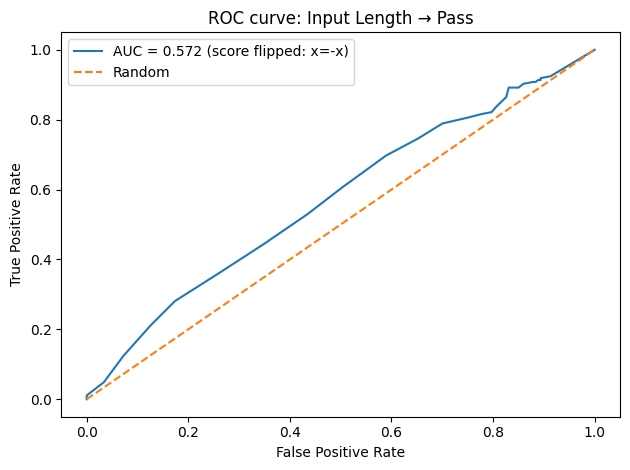

Plotting ROC curve for predictor: Full Length
lENS of x and y: 392 392


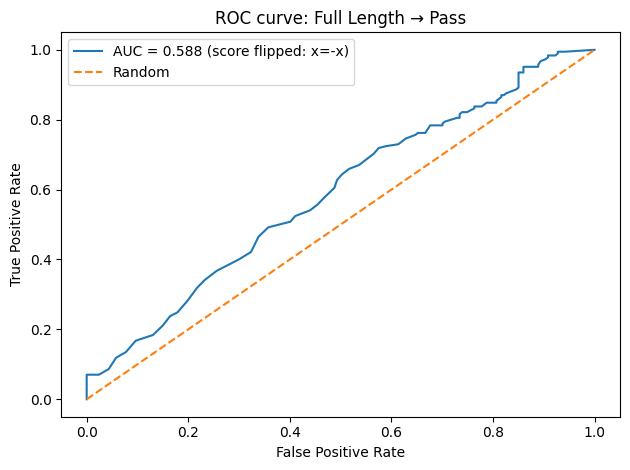

In [26]:
import numpy as np
import matplotlib.pyplot as plt  # BUGFIX: missing import
from sklearn.metrics import roc_curve, roc_auc_score

def _normalize_list_int_to_list_float(
    lst: list[int],
    *,
    method: str = "robust",   # "robust" | "zscore" | "minmax"
    clip: float = 3.0,        # used for robust / zscore
    eps: float = 1e-8
) -> np.ndarray:
    x = np.asarray(lst, dtype=float)
    if x.size == 0:
        return x

    if method == "robust":
        med = np.median(x)
        q1, q3 = np.percentile(x, [25, 75])
        iqr = max(q3 - q1, eps)
        z = (x - med) / iqr
        z = np.clip(z, -clip, clip)
        x_norm = (z + clip) / (2 * clip)

    elif method == "zscore":
        mu = x.mean()
        sigma = max(x.std(), eps)
        z = (x - mu) / sigma
        z = np.clip(z, -clip, clip)
        x_norm = (z + clip) / (2 * clip)

    elif method == "minmax":
        lo, hi = x.min(), x.max()
        if hi - lo < eps:
            return np.full_like(x, 0.5, dtype=float)
        x_norm = (x - lo) / (hi - lo)

    else:
        raise ValueError(f"Unknown method: {method}")

    return x_norm.astype(float)

def _plot_roc_curve(predictions: list[int], labels: list[bool], predictor_name: str):
    x = _normalize_list_int_to_list_float(predictions, method="robust", clip=3.0)
    y = np.asarray(labels, dtype=int)

    print(f"Plotting ROC curve for predictor: {predictor_name}")
    print("lENS of x and y:", len(x), len(y))
    assert len(y) == len(x)
    assert set(np.unique(y)).issubset({0, 1})

    auc = roc_auc_score(y, x)
    flipped = False

    # BUGFIX: x is a Python list in your version; -x would error.
    # Make x a numpy array (done above) or do: x = (-np.asarray(x)).tolist()
    if auc < 0.5:
        x = -x
        auc = roc_auc_score(y, x)
        flipped = True

    fpr, tpr, _ = roc_curve(y, x)

    plt.figure()
    plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}" + (" (score flipped: x=-x)" if flipped else ""))
    plt.plot([0, 1], [0, 1], linestyle="--", label="Random")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC curve: {predictor_name} → Pass")
    plt.legend()
    plt.tight_layout()
    plt.show()

# usage
input_lens = [entry["input_len"] for entry in data]
full_lens = [entry["full_len"] for entry in data]
success_labels = [entry["instruct_pass"] for entry in data]

_plot_roc_curve(input_lens, success_labels, predictor_name="Input Length")
_plot_roc_curve(full_lens, success_labels, predictor_name="Full Length")


In [27]:
with open("/work/pi_jensen_umass_edu/abhishekmish_umass_edu/plan_trace/outputs/planning_scale/base/plan_rate_dict.json", "r") as f:
    plan_rate_dict = json.load(f)

In [28]:
for k, v in plan_rate_dict.items():
    print(f"Max Coeff: {k}, Plan Rate Series: {len(v)}")

Max Coeff: -200, Plan Rate Series: 96
Max Coeff: -175, Plan Rate Series: 96
Max Coeff: -150, Plan Rate Series: 96
Max Coeff: -100, Plan Rate Series: 96
Max Coeff: -75, Plan Rate Series: 96
Max Coeff: -50, Plan Rate Series: 96
Max Coeff: -25, Plan Rate Series: 96
Max Coeff: 0, Plan Rate Series: 96


In [29]:
# Missing prompt: 24
# Missing prompt: 54
# Missing prompt: 78
# Missing prompt: 84

In [30]:
from scipy.stats import spearmanr

def _compute_spearmanr(x: list[float], y: list[float]):
    rho, p = spearmanr(x, y)
    return rho, p

# def _compute_spearman_between_length_and_plan_rates(
#     lengths: list[int],
#     success_labels: list[bool]
# ):
#     x = np.asarray(lengths, dtype=float)
#     y = np.asarray(success_labels, dtype=int)

#     assert len(x) == len(y)

#     rho, p = spearmanr(x, y)
#     return rho, p

### correlation n
input_lens = [entry["input_len"] for idx, entry in enumerate(data[1:101]) if idx not in {24, 54, 78, 84}]
full_lens = [entry["full_len"] for idx, entry in enumerate(data[1:101]) if idx not in {24, 54, 78, 84}]
input_len_norm = _normalize_list_int_to_list_float(input_lens, method="robust", clip=3.0)
full_len_norm = _normalize_list_int_to_list_float(full_lens, method="robust", clip=3.0)
for k, v in plan_rate_dict.items():
    plan_rates = v
    # plan_rates_norm = _normalize_list_int_to_list_float(plan_rates, method="robust", clip=3.0)
    rho_input, p_input = _compute_spearmanr(input_len_norm, plan_rates)
    rho_full, p_full = _compute_spearmanr(full_len_norm, plan_rates)
    print(f"Plan Coeff: {k}")
    print(f"  Spearmanr between Input Length and Plan Rate: rho={rho_input:.4f}, p={p_input:.4e}")
    print(f"  Spearmanr between Full Length and Plan Rate: rho={rho_full:.4f}, p={p_full:.4e}")

Plan Coeff: -200
  Spearmanr between Input Length and Plan Rate: rho=-0.0564, p=5.8499e-01
  Spearmanr between Full Length and Plan Rate: rho=0.2083, p=4.1729e-02
Plan Coeff: -175
  Spearmanr between Input Length and Plan Rate: rho=-0.0374, p=7.1736e-01
  Spearmanr between Full Length and Plan Rate: rho=0.2216, p=3.0023e-02
Plan Coeff: -150
  Spearmanr between Input Length and Plan Rate: rho=-0.0311, p=7.6354e-01
  Spearmanr between Full Length and Plan Rate: rho=0.2443, p=1.6449e-02
Plan Coeff: -100
  Spearmanr between Input Length and Plan Rate: rho=0.0058, p=9.5490e-01
  Spearmanr between Full Length and Plan Rate: rho=0.2173, p=3.3474e-02
Plan Coeff: -75
  Spearmanr between Input Length and Plan Rate: rho=-0.0898, p=3.8426e-01
  Spearmanr between Full Length and Plan Rate: rho=0.1691, p=9.9576e-02
Plan Coeff: -50
  Spearmanr between Input Length and Plan Rate: rho=0.0045, p=9.6547e-01
  Spearmanr between Full Length and Plan Rate: rho=0.2535, p=1.2703e-02
Plan Coeff: -25
  Spearman

/scratch/login/ipykernel_2078185/3386484354.py:4: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, p = spearmanr(x, y)


Normalizing plan rates for coeff -200, number of entries: 96 with full lengths: 96
Plotting ROC curve for predictor: Plan Rate Normalized by Full Length (Coeff=-200)
lENS of x and y: 96 96


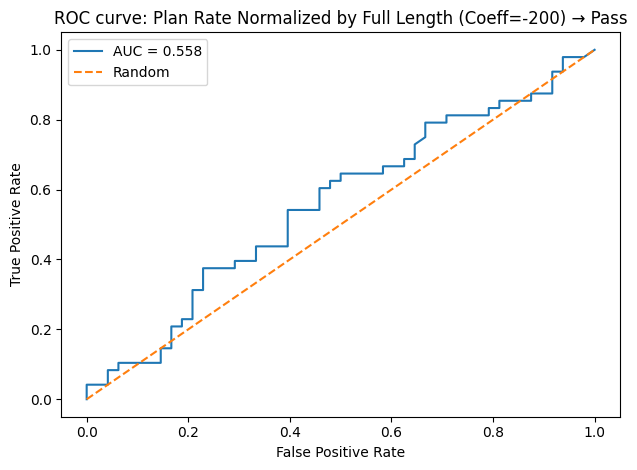

Normalizing plan rates for coeff -175, number of entries: 96 with full lengths: 96
Plotting ROC curve for predictor: Plan Rate Normalized by Full Length (Coeff=-175)
lENS of x and y: 96 96


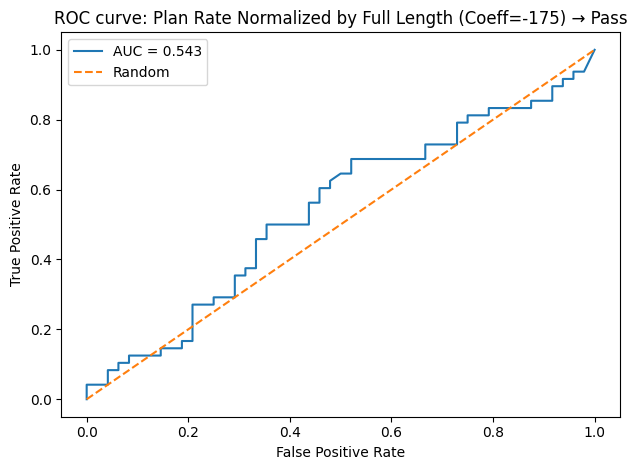

Normalizing plan rates for coeff -150, number of entries: 96 with full lengths: 96
Plotting ROC curve for predictor: Plan Rate Normalized by Full Length (Coeff=-150)
lENS of x and y: 96 96


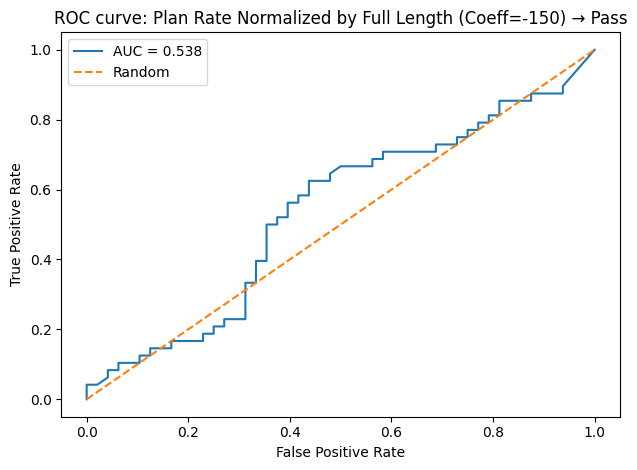

Normalizing plan rates for coeff -100, number of entries: 96 with full lengths: 96
Plotting ROC curve for predictor: Plan Rate Normalized by Full Length (Coeff=-100)
lENS of x and y: 96 96


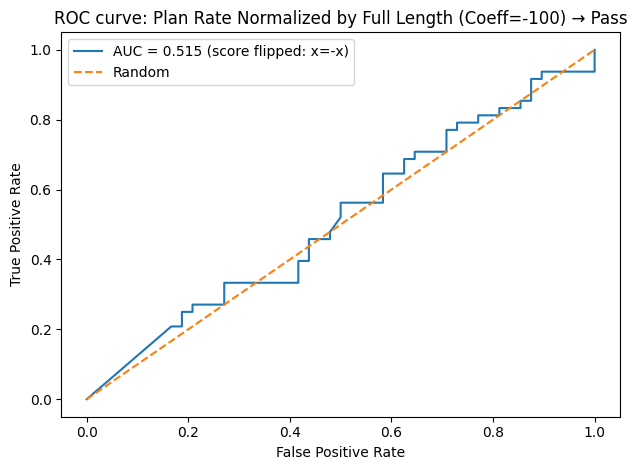

Normalizing plan rates for coeff -75, number of entries: 96 with full lengths: 96
Plotting ROC curve for predictor: Plan Rate Normalized by Full Length (Coeff=-75)
lENS of x and y: 96 96


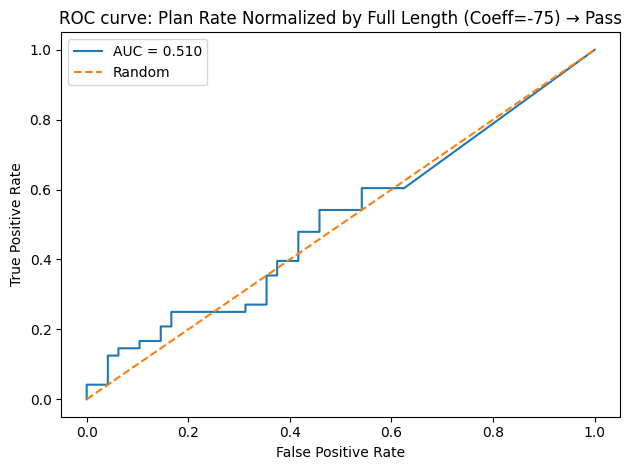

Normalizing plan rates for coeff -50, number of entries: 96 with full lengths: 96
Plotting ROC curve for predictor: Plan Rate Normalized by Full Length (Coeff=-50)
lENS of x and y: 96 96


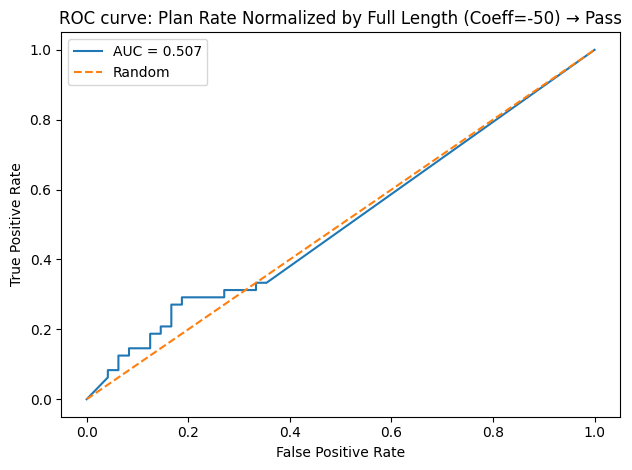

Normalizing plan rates for coeff -25, number of entries: 96 with full lengths: 96
Plotting ROC curve for predictor: Plan Rate Normalized by Full Length (Coeff=-25)
lENS of x and y: 96 96


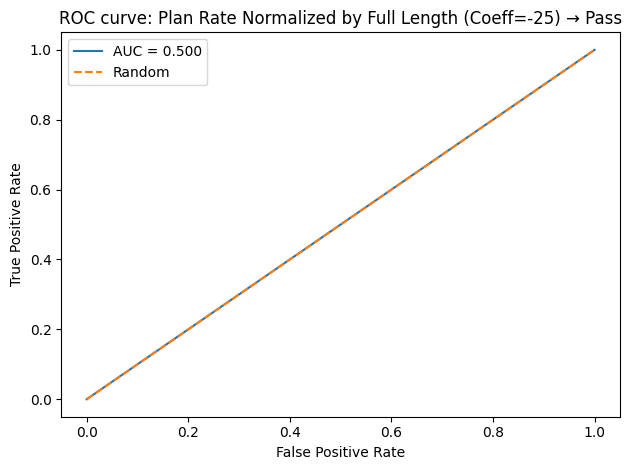

Normalizing plan rates for coeff 0, number of entries: 96 with full lengths: 96
Plotting ROC curve for predictor: Plan Rate Normalized by Full Length (Coeff=0)
lENS of x and y: 96 96


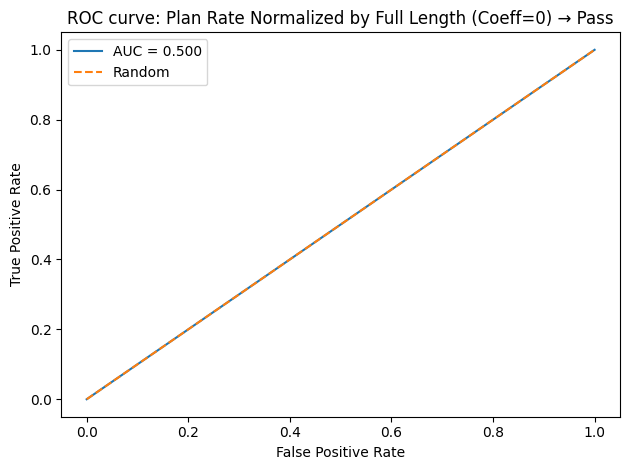

In [32]:
def _normalize_plan_rates_by_full_length(max_coeff: str):
    plan_rates = plan_rate_dict[max_coeff]
    print(f"Normalizing plan rates for coeff {max_coeff}, number of entries: {len(plan_rates)} with full lengths: {len(full_lens)}")
    plan_rates_div_full_len = [x / y for x, y in zip(plan_rates, full_lens)]
    plan_rates_div_full_len_norm = _normalize_list_int_to_list_float(plan_rates_div_full_len, method="robust", clip=3.0)

    return plan_rates_div_full_len_norm

## now, calculate the ROC curves for normalized plan rates.
for k in plan_rate_dict.keys():
    plan_rates_norm = _normalize_plan_rates_by_full_length(k)
    cut_success_labels = [entry["instruct_pass"] for idx, entry in enumerate(data[1:101]) if idx not in {24, 54, 78, 84}]
    _plot_roc_curve(plan_rates_norm, cut_success_labels, predictor_name=f"Plan Rate Normalized by Full Length (Coeff={k})")